In [1]:
import pandas as pd

# -----------------------------
# Load
# -----------------------------
import glob

files = glob.glob("data/*.csv")

dfs = [pd.read_csv(f) for f in files]

df = pd.concat(dfs, ignore_index=True)

df.to_csv("merged.csv", index=False)

# -----------------------------
# 1) Missing value report (count + %)
# -----------------------------
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
    })
    .sort_values("missing_count", ascending=False)
)
print("Missing value summary:\n", missing_summary)

Missing value summary:
                            missing_count  missing_pct
Eircode                             9991        99.91
Property Size Description           8497        84.97
lat                                 1494        14.94
lng                                 1494        14.94
Date of Sale (dd/mm/yyyy)              0         0.00
Address                                0         0.00
County                                 0         0.00
Price (€)                              0         0.00
Not Full Market Price                  0         0.00
VAT Exclusive                          0         0.00
Description of Property                0         0.00


In [2]:
df = df.drop(columns=["Property Size Description"])
df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price (€),Not Full Market Price,VAT Exclusive,Description of Property,lat,lng
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,"€125,000.00",No,No,Second-Hand Dwelling house /Apartment,53.327500,-8.21944
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,"€100,000.00",No,No,Second-Hand Dwelling house /Apartment,54.950000,-7.73333
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,"€175,000.00",Yes,Yes,New Dwelling house /Apartment,53.333060,-6.24889
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,"€65,000.00",No,No,Second-Hand Dwelling house /Apartment,53.990830,-7.36056
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,"€190,000.00",No,No,Second-Hand Dwelling house /Apartment,53.296101,-6.49200


  Indicator         Value
0      Mean    257.206687
1       Std    497.763075
2  Skewness     32.632593
3  Kurtosis   1470.823151
4       Min      6.340000
5       Max  26000.000000
6    Median    192.500000


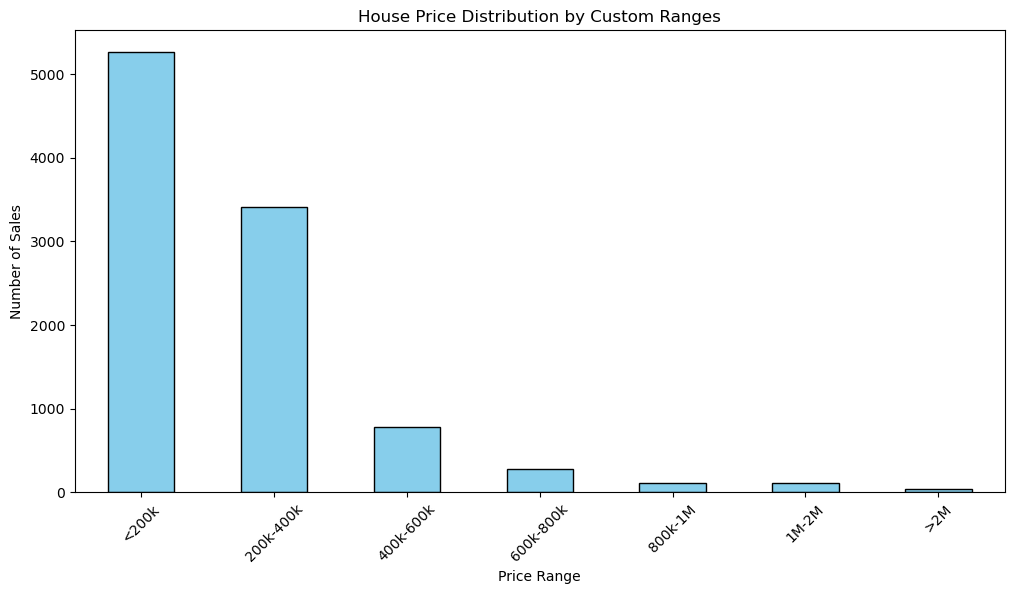

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. string to float
df['Price(1,000 €)'] = df['Price (€)'].replace(r'[€,]', '', regex=True).astype(float) / 1000
df['Price(1,000 €)'] = df['Price(1,000 €)'].round(2)

# 2. statistics summary for price
stats = {
    'Mean': df['Price(1,000 €)'].mean(),
    'Std': df['Price(1,000 €)'].std(),
    'Skewness': df['Price(1,000 €)'].skew(),
    'Kurtosis': df['Price(1,000 €)'].kurt(),
    'Min': df['Price(1,000 €)'].min(),
    'Max': df['Price(1,000 €)'].max(),
    'Median': df['Price(1,000 €)'].median()
}

stats_df = pd.DataFrame(stats.items(), columns=['Indicator', 'Value'])
print(stats_df)

# 3. lables for bins
bins = [0, 200, 400, 600, 800, 1000, 2000, float('inf')]
labels = ['<200k', '200k-400k', '400k-600k', '600k-800k', '800k-1M', '1M-2M', '>2M']

# 4. binning and calculating
df['Price_Range'] = pd.cut(df['Price(1,000 €)'], bins=bins, labels=labels)
counts = df['Price_Range'].value_counts().reindex(labels) # 保持顺序

# 5. visualization
plt.figure(figsize=(12, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('House Price Distribution by Custom Ranges')
plt.ylabel('Number of Sales')
plt.xlabel('Price Range')
plt.xticks(rotation=45)
plt.show()

In [4]:
# calculate price threshold based on IQR method
Q1 = df['Price(1,000 €)'].quantile(0.25)
Q3 = df['Price(1,000 €)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 0.5 * IQR
upper_bound = Q3 + 4 * IQR

print("lower_bound: ", lower_bound)
print("higher_bound: ", upper_bound)

lower_bound:  15.0
higher_bound:  1060.0


sample size: 10000
abnormal value: 181


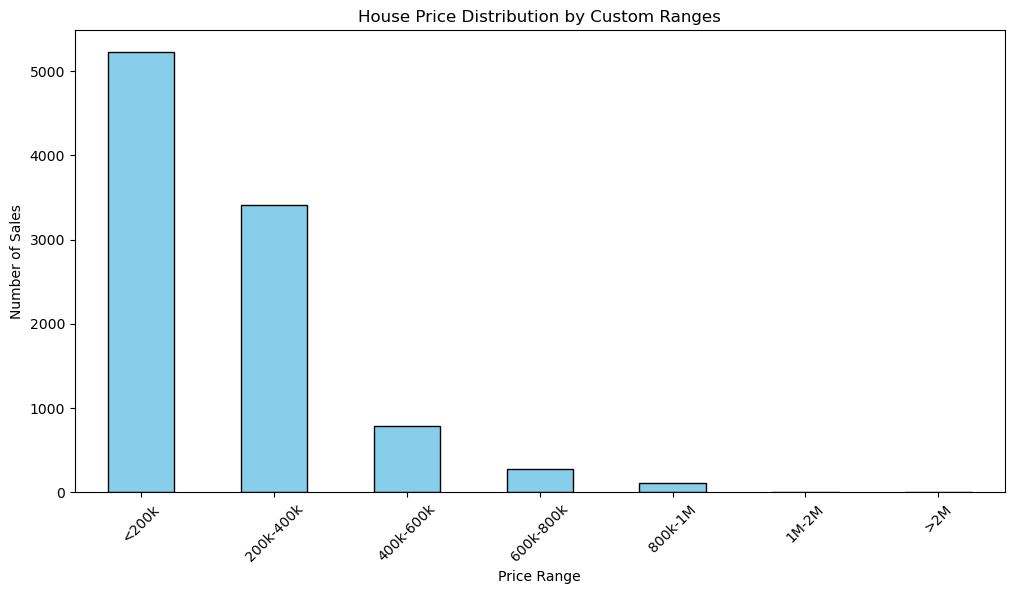

In [5]:
# 4. detect outliers
outliers = df[(df['Price(1,000 €)'] < lower_bound) | (df['Price(1,000 €)'] > upper_bound)]

print(f"sample size: {len(df)}")
print(f"abnormal value: {len(outliers)}")

df = df[(df['Price(1,000 €)'] >= lower_bound) & (df['Price(1,000 €)'] <= upper_bound)].copy()

# 5.binning and visualization
df['Price_Range'] = pd.cut(df['Price(1,000 €)'], bins=bins, labels=labels)
counts = df['Price_Range'].value_counts().reindex(labels) # 保持顺序

plt.figure(figsize=(12, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('House Price Distribution by Custom Ranges')
plt.ylabel('Number of Sales')
plt.xlabel('Price Range')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Year / Month / Quarter from sale date
# -----------------------------
df["Date of Sale"] = pd.to_datetime(
    df["Date of Sale (dd/mm/yyyy)"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["year_quarter"] = df["Date of Sale"].dt.to_period("Q").astype(str)

# -----------------------------
# 5) Clean Price (€): remove €, commas, weird chars -> integer
# -----------------------------
# Keep only digits and decimal point, coerce invalid to NaN
price_numeric = pd.to_numeric(
    df["Price (€)"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
    errors="coerce"
)

# Convert to integer euros (rounded to nearest euro). If you prefer floor: use .astype("Int64") directly after removing decimals.
df["price_eur"] = price_numeric.round().astype("Int64")

# (optional) drop original price string column
df = df.drop(columns=["Price (€)"])

# -----------------------------
# 6) Convert Yes/No columns to binary (Yes=1, No=0)
# -----------------------------
yn_map = {"Yes": 1, "No": 0}
df["Not Full Market Price"] = df["Not Full Market Price"].map(yn_map).astype("Int64")
df["VAT Exclusive"] = df["VAT Exclusive"].map(yn_map).astype("Int64")

# -----------------------------
# Quick sanity checks
# -----------------------------
print("\nData types snapshot:\n", df.dtypes)
print("\nPreview:\n", df.head())
print("\nRemaining missing values (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))



Data types snapshot:
 Date of Sale (dd/mm/yyyy)            object
Address                              object
County                               object
Eircode                              object
Not Full Market Price                 Int64
VAT Exclusive                         Int64
Description of Property              object
lat                                 float64
lng                                 float64
Price(1,000 €)                      float64
Price_Range                        category
Date of Sale                 datetime64[ns]
year_quarter                         object
price_eur                             Int64
dtype: object

Preview:
   Date of Sale (dd/mm/yyyy)                                          Address  \
0                22/12/2016                 LISMIHILL, KILLIMOR, BALLINASLOE   
1                30/06/2016               BARTON HOUSE, OLDTOWN, LETTERKENNY   
2                20/12/2016  Apartment 84, Hampton Wood Avenue, Hampton Wood   
3               

In [7]:
# ---------------------------------------
# Convert Description of Property to binary variable
# 1 = New property
# 0 = Second-hand property
# ---------------------------------------

# Step 1: standardize Irish and English labels
df["Description of Property"] = df["Description of Property"].replace({
    "Teach/Árasán Cónaithe Atháimhe": "Second-Hand Dwelling house /Apartment",
    "Teach/Árasán Cónaithe Nua": "New Dwelling house /Apartment"
})

# Step 2: create binary variable
df["is_new_property"] = (
    df["Description of Property"] == "New Dwelling house /Apartment"
).astype(int)

# Step 3: verify conversion
print(df["is_new_property"].value_counts())

# Step 4 (optional but recommended): drop original text column
df = df.drop(columns=["Description of Property"])

# Step 5: preview result
print(df[["is_new_property"]].head())

is_new_property
0    8330
1    1489
Name: count, dtype: int64
   is_new_property
0                0
1                0
2                1
3                0
4                0


In [8]:
df.head(5)

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,Date of Sale,year_quarter,price_eur,is_new_property
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,0,0,53.327500,-8.21944,125.0,<200k,2016-12-22,2016Q4,125000,0
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,0,0,54.950000,-7.73333,100.0,<200k,2016-06-30,2016Q2,100000,0
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,1,1,53.333060,-6.24889,175.0,<200k,2016-12-20,2016Q4,175000,1
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,0,0,53.990830,-7.36056,65.0,<200k,2016-05-24,2016Q2,65000,0
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,0,0,53.296101,-6.49200,190.0,<200k,2016-08-22,2016Q3,190000,0


In [9]:
from math import radians, sin, cos, sqrt, atan2

# =========================
# Config
# =========================

COUNTY_COL = "County"   # change if your column name differs
LAT_COL    = "lat"      # must exist in your data (from geocoding)
LNG_COL    = "lng"      # must exist in your data (from geocoding)

OUT_COL = "distance_to_local_economic_center_km"

# =========================
# County -> local economic center (approx)
# =========================
# NOTE:
# - These are practical “center city/town” coordinates for each county.
# - If your county names differ (e.g., "Co. Dublin", "Dublin City"), the normalizer below helps.
county_center = {
    "carlo": (52.8365, -6.9341),          # Carlow
    "cavan": (53.9900, -7.3600),          # Cavan
    "clare": (52.6638, -8.6267),          # Limerick (strongest nearby hub); alternative: Ennis
    "cork": (51.8985, -8.4756),           # Cork
    "donegal": (54.6540, -8.1100),        # Letterkenny-ish region
    "dublin": (53.3498, -6.2603),         # Dublin
    "galway": (53.2707, -9.0568),         # Galway
    "kerry": (52.1545, -9.5669),          # Tralee/Killarney area
    "kildare": (53.1593, -6.9099),        # Naas
    "kilkenny": (52.6541, -7.2448),       # Kilkenny
    "laois": (53.0340, -7.2990),          # Portlaoise
    "leitrim": (54.1250, -8.0000),        # Carrick-on-Shannon area
    "limerick": (52.6638, -8.6267),       # Limerick
    "longford": (53.7275, -7.7930),       # Longford
    "louth": (53.9979, -6.4023),          # Dundalk/Drogheda corridor
    "mayo": (53.8550, -9.2980),           # Castlebar/Westport area
    "meath": (53.6055, -6.6564),          # Navan
    "monaghan": (54.2492, -6.9683),       # Monaghan
    "offaly": (53.2734, -7.7783),         # Tullamore
    "roscommon": (53.7598, -8.2682),      # Roscommon
    "sligo": (54.2766, -8.4761),          # Sligo
    "tipperary": (52.4738, -8.1557),      # Thurles/Cashel area
    "waterford": (52.2593, -7.1101),      # Waterford
    "westmeath": (53.5266, -7.3386),      # Mullingar/Athlone corridor
    "wexford": (52.3369, -6.4633),        # Wexford
    "wicklow": (52.9862, -6.3675),        # Wicklow
}

# Some datasets use "Laois" as "Queen's County" historically (rare); add aliases if needed.
county_alias = {
    "co dublin": "dublin",
    "county dublin": "dublin",
    "dublin city": "dublin",
    "co cork": "cork",
    "county cork": "cork",
    "co galway": "galway",
    "county galway": "galway",
    "co limerick": "limerick",
    "county limerick": "limerick",
    "co waterford": "waterford",
    "county waterford": "waterford",
}

def normalize_county(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = s.replace(".", "").replace(",", "")
    s = " ".join(s.split())
    # map aliases
    if s in county_alias:
        return county_alias[s]
    # also handle "co <name>"
    if s.startswith("co "):
        s2 = s[3:].strip()
        return county_alias.get(s, s2)
    if s.startswith("county "):
        return s[7:].strip()
    return s

# =========================
# Haversine distance (km)
# =========================
def haversine_km(lat1, lon1, lat2, lon2) -> float:
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def compute_distance(row) -> float | None:
    lat = row.get(LAT_COL, None)
    lng = row.get(LNG_COL, None)
    if pd.isna(lat) or pd.isna(lng):
        return None

    county_raw = row.get(COUNTY_COL, "")
    county = normalize_county(county_raw)
    if not county:
        return None

    center = county_center.get(county)
    if center is None:
        return None

    c_lat, c_lng = center
    return haversine_km(float(lat), float(lng), c_lat, c_lng)

# =========================
# Run
# =========================

# Create distance feature
df[OUT_COL] = df.apply(compute_distance, axis=1)

df.head(5)

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,Date of Sale,year_quarter,price_eur,is_new_property,distance_to_local_economic_center_km
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,NaN,0,0,53.327500,-8.21944,125.0,<200k,2016-12-22,2016Q4,125000,0,56.003110
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,NaN,0,0,54.950000,-7.73333,100.0,<200k,2016-06-30,2016Q2,100000,0,40.818330
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,NaN,1,1,53.333060,-6.24889,175.0,<200k,2016-12-20,2016Q4,175000,1,2.009631
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,NaN,0,0,53.990830,-7.36056,65.0,<200k,2016-05-24,2016Q2,65000,0,0.099288
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,NaN,0,0,53.296101,-6.49200,190.0,<200k,2016-08-22,2016Q3,190000,0,16.506682


In [10]:
df = df.drop("Eircode", axis=1)
df = df.dropna()
df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Price_Range,Date of Sale,year_quarter,price_eur,is_new_property,distance_to_local_economic_center_km
0,22/12/2016,"LISMIHILL, KILLIMOR, BALLINASLOE",Galway,0,0,53.327500,-8.21944,125.0,<200k,2016-12-22,2016Q4,125000,0,56.003110
1,30/06/2016,"BARTON HOUSE, OLDTOWN, LETTERKENNY",Donegal,0,0,54.950000,-7.73333,100.0,<200k,2016-06-30,2016Q2,100000,0,40.818330
2,20/12/2016,"Apartment 84, Hampton Wood Avenue, Hampton Wood",Dublin,1,1,53.333060,-6.24889,175.0,<200k,2016-12-20,2016Q4,175000,1,2.009631
3,24/05/2016,"8 THE BELFRY, COCK HILL, CHURCH VIEW",Cavan,0,0,53.990830,-7.36056,65.0,<200k,2016-05-24,2016Q2,65000,0,0.099288
4,22/08/2016,"8 THE PLACE, NEWCASTLE MANOR, NEWCASTLE",Dublin,0,0,53.296101,-6.49200,190.0,<200k,2016-08-22,2016Q3,190000,0,16.506682


In [11]:
df.isna().sum().sort_values(ascending=False)

Date of Sale (dd/mm/yyyy)               0
Address                                 0
County                                  0
Not Full Market Price                   0
VAT Exclusive                           0
lat                                     0
lng                                     0
Price(1,000 €)                          0
Price_Range                             0
Date of Sale                            0
year_quarter                            0
price_eur                               0
is_new_property                         0
distance_to_local_economic_center_km    0
dtype: int64

In [12]:
df.describe()

,Not Full Market Price,VAT Exclusive,lat,lng,"Price(1,000 €)",Date of Sale,price_eur,is_new_property,distance_to_local_economic_center_km
count,8280.0,8280.0,8280.000000,8280.000000,8280.000000,8280,8280.0,8280.000000,8280.000000
mean,0.043599,0.144565,53.110691,-7.367228,227.499162,2016-11-07 10:12:31.304347904,227499.15314,0.147464,14.233031
min,0.0,0.0,51.479000,-10.416670,15.000000,2016-01-01 00:00:00,15000.0,0.000000,0.052998
25%,0.0,0.0,52.656747,-8.469430,110.000000,2016-06-03 00:00:00,110000.0,0.000000,2.009631
50%,0.0,0.0,53.333060,-6.980280,190.000000,2016-10-10 00:00:00,190000.0,0.000000,8.644043
75%,0.0,0.0,53.385000,-6.248890,295.000000,2017-03-24 00:00:00,295000.0,0.000000,22.971562
max,1.0,1.0,55.376670,-6.038610,1050.000000,2017-12-29 00:00:00,1050000.0,1.000000,156.621534
std,0.204214,0.351683,0.687594,1.147061,165.506507,NaN,165506.531391,0.354589,15.799386


In [13]:
import statsmodels.formula.api as smf

df = df.rename(columns={
    "Price(1,000 €)": "price",
    "distance_to_local_economic_center_km": "distance",
    "Not Full Market Price": "not_full_price",
    "VAT Exclusive": "vatx",
    })

model = smf.ols(
    formula="price ~ distance + not_full_price + vatx + is_new_property + C(County) + C(year_quarter)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["County"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     637.9
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           8.29e-27
Time:                        13:34:38   Log-Likelihood:                -52382.
No. Observations:                8280   AIC:                         1.048e+05
Df Residuals:                    8244   BIC:                         1.051e+05
Df Model:                          35                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 11
  warnings.warn('covariance of constraints does not have full '
